# OEMMPA Walkthrough

This notebook demonstrates the dataframe-first query layer added for interactive MMP analysis. It uses the same compact potency dataset as `tests/python/test_query_layer.py`, then walks through pair filtering, SMARTS constraints, transform statistics, product generation, and molecule-level opportunities.

## Setup

When running from a source checkout, add `python/` to `sys.path` so the local build is used. The OpenEye license is picked up from the environment, with a local checkout fallback if that file exists.

In [1]:
from oemmpa import analyze_dataframe
from openeye import oechem
from pathlib import Path

import cnotebook
import importlib.util
import os
import pandas as pd
import sys
import tempfile

# Path to example data
DATA_ROOT = Path("__file").parent / "tests" / "data"

## Load Example Data

We are just loading five example molecules with `pIC50` values artifically created so that methyl-to-hydroxyl substitutions improve potency. Let's see if we can pick that up!

In [2]:
# Some simple test data
df = pd.DataFrame({
    "smiles": [
        "Cc1ccccc1",
        "Oc1ccccc1",
        "Cc1ccccn1",
        "Oc1ccccn1",
        "Nc1ccccc1",
        "Clc1ccccc1"
    ],
    "id": [
        "toluene",
        "phenol",
        "methyl_pyridine",
        "hydroxy_pyridine",
        "aniline",
        "chlorophenyl"
    ],
    "pIC50": [6.0, 7.0, 5.0, 8.0, 6.5, 7.0],
})

# Dispaly it
df

,smiles,id,pIC50
0,Cc1ccccc1,toluene,6.0
1,Oc1ccccc1,phenol,7.0
2,Cc1ccccn1,methyl_pyridine,5.0
3,Oc1ccccn1,hydroxy_pyridine,8.0
4,Nc1ccccc1,aniline,6.5
5,Clc1ccccc1,chlorophenyl,7.0


## Analyze The Dataframe

The `analyze_dataframe` function loads molecules, loads numeric properties, runs MMP analysis, and returns an `AnalysisResult` with pair, transform, generation, and opportunity helpers. This is a Python-level helper function intended to make analyses effortless.

In [3]:


analysis = analyze_dataframe(
    df,
    smiles="smiles",
    id="id",
    properties=["pIC50"],
)

summary = {
    "accepted_rows": analysis.load_report.accepted_count,
    "rejected_rows": analysis.load_report.rejected_count,
    "pairs": len(analysis.pairs),
    "transforms": len(analysis.transforms),
}
summary


{'accepted_rows': 6, 'rejected_rows': 0, 'pairs': 18, 'transforms': 14}

## Find Matched Pairs That Improve Potency

"Potency" can be a tricky word. If you're talking about percent inhibition, higher is better, if you're talking about IC50, lower is better, if you're talking about pIC50, higher is better. It can cause a lot of confusion. For that reason, we have a couple of different semantics for looking at matched pairs, depending on what most comfortably fits your thinking.

Firstly, there are these two functions:

* `improves()`: which implies higher numbers are better
* `decreases()`: which implies that lower numbers are better

These may be unsatisfying to your mental model of potency for your system, so there is a `higher_is_better` parameter for semantic equivalence. These are exactly equivalent:

* **Higher numbers are better:** `improves()` or `decreases(higher_is_better=True)`
* **Lower numbers are better:** `decreases()` or `improves(higher_is_better=False)`

It's just there for you to feel more comfortable about the language you choose to use for your endpoint. For the example below, we're using pIC50, so higher is better and we'll simply use `improves()`.

In [4]:
# Limit our output DataFrame to these columns
pair_columns = [
    "source_id",
    "target_id",
    "constant",
    "source_variable",
    "target_variable",
    "transform",
    "pIC50_delta",
]

improving_pairs = analysis.pairs.improves("pIC50")

# Convert to DataFrame and display
improving_pairs_df = improving_pairs.to_dataframe()[pair_columns]
improving_pairs_df

,source_id,target_id,constant,source_variable,target_variable,transform,pIC50_delta
0,methyl_pyridine,toluene,[*:1]C,[*:1]c1ccccn1,[*:1]c1ccccc1,[*:1]c1ccccn1>>[*:1]c1ccccc1,1.0
1,phenol,hydroxy_pyridine,[*:1]O,[*:1]c1ccccc1,[*:1]c1ccccn1,[*:1]c1ccccc1>>[*:1]c1ccccn1,1.0
2,toluene,phenol,[*:1]c1ccccc1,[*:1]C,[*:1]O,[*:1]C>>[*:1]O,1.0
3,toluene,aniline,[*:1]c1ccccc1,[*:1]C,[*:1]N,[*:1]C>>[*:1]N,0.5
4,toluene,chlorophenyl,[*:1]c1ccccc1,[*:1]C,[*:1]Cl,[*:1]C>>[*:1]Cl,1.0
5,aniline,phenol,[*:1]c1ccccc1,[*:1]N,[*:1]O,[*:1]N>>[*:1]O,0.5
6,aniline,chlorophenyl,[*:1]c1ccccc1,[*:1]N,[*:1]Cl,[*:1]N>>[*:1]Cl,0.5
7,methyl_pyridine,hydroxy_pyridine,[*:1]c1ccccn1,[*:1]C,[*:1]O,[*:1]C>>[*:1]O,3.0


We can use [`cnotebook`](https://github.com/scott-arne/cnotebook) to visualize each of these columns. We'll convert `constant`, `source_variable`, and `target_variable` to molecule columns for visualization. Note that we could convert `transform` to a query column in `cnotebook` to visualize it, but SMIRKS aren't really depicted in a very informative way.

,source_id,target_id,constant,source_variable,target_variable,transform,pIC50_delta
0,methyl_pyridine,toluene,,,,[*:1]c1ccccn1>>[*:1]c1ccccc1,1.0
1,phenol,hydroxy_pyridine,,,,[*:1]c1ccccc1>>[*:1]c1ccccn1,1.0
2,toluene,phenol,,,,[*:1]C>>[*:1]O,1.0
3,toluene,aniline,,,,[*:1]C>>[*:1]N,0.5
4,toluene,chlorophenyl,,,,[*:1]C>>[*:1]Cl,1.0
5,aniline,phenol,,,,[*:1]N>>[*:1]O,0.5
6,aniline,chlorophenyl,,,,[*:1]N>>[*:1]Cl,0.5
7,methyl_pyridine,hydroxy_pyridine,,,,[*:1]C>>[*:1]O,3.0

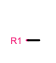
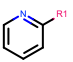
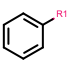
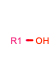
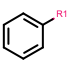
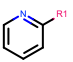
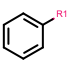
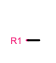
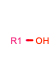
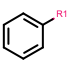
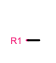
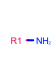
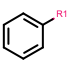
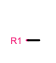
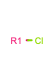
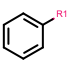
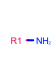
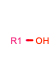
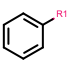
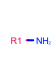
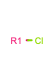
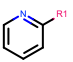
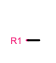
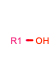

In [5]:
improving_pairs_df.chem.as_molecule("constant", inplace=True)
improving_pairs_df.chem.as_molecule("source_variable", inplace=True)
improving_pairs_df.chem.as_molecule("target_variable", inplace=True)

improving_pairs_df

You can simply ask for molecule objects back when getting the DataFrame. Note in this case, you get the OEQMol objects for `transform`.

,source_id,target_id,constant,source_variable,target_variable,transform,pIC50_delta
0,methyl_pyridine,toluene,,,,,1.0
1,phenol,hydroxy_pyridine,,,,,1.0
2,toluene,phenol,,,,,1.0
3,toluene,aniline,,,,,0.5
4,toluene,chlorophenyl,,,,,1.0
5,aniline,phenol,,,,,0.5
6,aniline,chlorophenyl,,,,,0.5
7,methyl_pyridine,hydroxy_pyridine,,,,,3.0

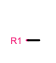
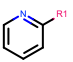
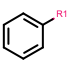
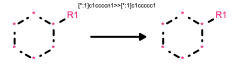
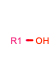
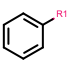
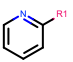
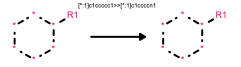
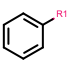
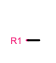
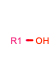
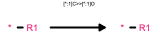
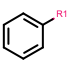
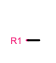
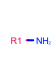
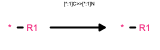
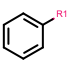
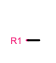
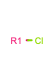
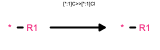
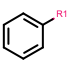
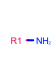
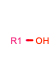
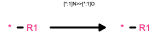
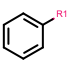
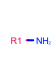
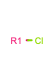
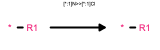
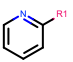
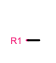
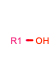
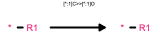

In [6]:
analysis.pairs.improves("pIC50").to_dataframe(molecules=True)[pair_columns]

## Find Matched Pairs That Decrease Potency

Use `decreases()` for pIC50, as discussed above.

,source_id,target_id,constant,source_variable,target_variable,transform,pIC50_delta
0,toluene,methyl_pyridine,,,,[*:1]c1ccccc1>>[*:1]c1ccccn1,-1.0
1,hydroxy_pyridine,phenol,,,,[*:1]c1ccccn1>>[*:1]c1ccccc1,-1.0
2,phenol,toluene,,,,[*:1]O>>[*:1]C,-1.0
3,phenol,aniline,,,,[*:1]O>>[*:1]N,-0.5
4,aniline,toluene,,,,[*:1]N>>[*:1]C,-0.5
5,chlorophenyl,toluene,,,,[*:1]Cl>>[*:1]C,-1.0
6,chlorophenyl,aniline,,,,[*:1]Cl>>[*:1]N,-0.5
7,hydroxy_pyridine,methyl_pyridine,,,,[*:1]O>>[*:1]C,-3.0

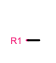
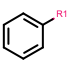
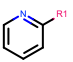
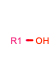
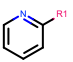
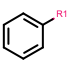
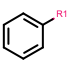
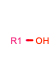
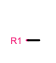
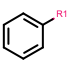
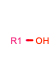
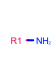
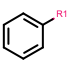
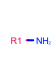
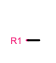
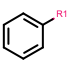
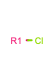
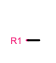
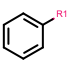
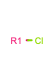
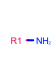
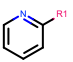
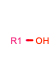
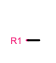

In [7]:
# Do the analysis
decreasing_pairs = analysis.pairs.decreases("pIC50")

# Get the DataFrame
decreasing_pairs_df = decreasing_pairs.to_dataframe()[pair_columns]

# Add visualizations
decreasing_pairs_df.chem.as_molecule("constant", inplace=True)
decreasing_pairs_df.chem.as_molecule("source_variable", inplace=True)
decreasing_pairs_df.chem.as_molecule("target_variable", inplace=True)

# Display
decreasing_pairs_df

## Find Matched Pairs That Do Not Change Potency

Because `improves` and `decreases` require *some* degree of change, there's a way to get matched pairs with exactly no change whatsoever for the propery of interest. You get the symmetric pairs here, since there's no directionality.

,source_id,target_id,constant,source_variable,target_variable,transform,pIC50_delta
0,phenol,chlorophenyl,,,,[*:1]O>>[*:1]Cl,0.0
1,chlorophenyl,phenol,,,,[*:1]Cl>>[*:1]O,0.0

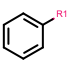
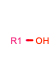
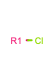
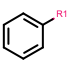
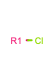
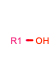

In [8]:
# Do the analysis
neutral_pairs = analysis.pairs.unchanged("pIC50")

# Get the DataFrame
neutral_pairs_df = neutral_pairs.to_dataframe()[pair_columns]

# Add visualizations
neutral_pairs_df.chem.as_molecule("constant", inplace=True)
neutral_pairs_df.chem.as_molecule("source_variable", inplace=True)
neutral_pairs_df.chem.as_molecule("target_variable", inplace=True)

# Display
neutral_pairs_df

## Constrain Constant And R-Group Regions With SMARTS

You can filter pairs using SMARTS patterns. Note that the directionality (i.e., `source_id` and `target_id`) are determined by the function you applied above, either `increases()` or `decreases()`. In this case, we will use the results form `improves()`, so `target_id` will always be more favorible than `source_id`.

**I only want pairs where a phenyl is part of the constant region**

,source_id,target_id,constant,source_variable,target_variable,transform,pIC50_delta
0,toluene,phenol,,,,,1.0
1,toluene,aniline,,,,,0.5
2,toluene,chlorophenyl,,,,,1.0
3,aniline,phenol,,,,,0.5
4,aniline,chlorophenyl,,,,,0.5

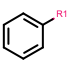
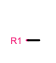
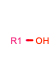
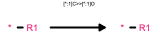
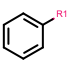
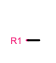
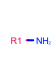
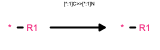
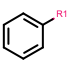
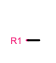
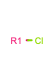
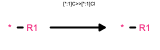
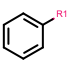
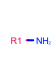
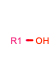
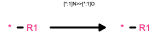
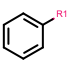
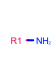
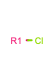
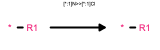

In [9]:
phenyl_constant_pairs = improving_pairs.where_constant_matches("c1ccccc1")
phenyl_constant_pairs.to_dataframe(molecules=True)[pair_columns]

**I only want pairs where the source molecule contains a methyl group in the variable region.**

,source_id,target_id,constant,source_variable,target_variable,transform,pIC50_delta
0,toluene,phenol,,,,,1.0
1,toluene,aniline,,,,,0.5
2,toluene,chlorophenyl,,,,,1.0
3,methyl_pyridine,hydroxy_pyridine,,,,,3.0

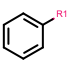
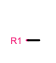
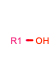
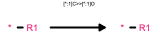
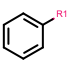
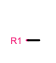
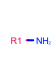
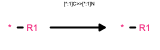
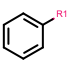
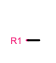
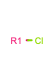
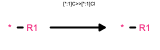
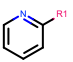
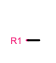
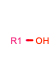
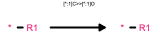

In [10]:
from_carbon_pairs = improving_pairs.where_from_matches("[CH3]")
from_carbon_pairs.to_dataframe(molecules=True)[pair_columns]

**I only want pairs where target molecule contains a hydroxyl.**

,source_id,target_id,constant,source_variable,target_variable,transform,pIC50_delta
0,toluene,phenol,,,,,1.0
1,aniline,phenol,,,,,0.5
2,methyl_pyridine,hydroxy_pyridine,,,,,3.0

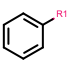
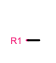
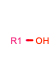
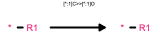
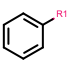
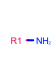
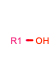
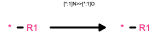
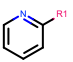
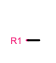
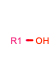
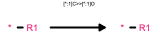

In [11]:
to_hydroxyl_pairs = improving_pairs.where_to_matches("[OH]")
to_hydroxyl_pairs.to_dataframe(molecules=True)[pair_columns]

**I only want pairs going from methyl to hydroxyl**

,source_id,target_id,constant,source_variable,target_variable,transform,pIC50_delta
0,toluene,phenol,,,,,1.0
1,methyl_pyridine,hydroxy_pyridine,,,,,3.0

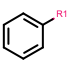
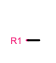
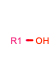
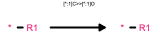
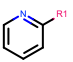
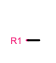
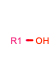
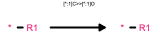

In [12]:
from_methyl_to_hydroxyl_pairs = improving_pairs.where_from_matches("[CH3]").where_to_matches("[OH]")
from_methyl_to_hydroxyl_pairs.to_dataframe(molecules=True)[pair_columns]

## Analyze Improving Transformations

`analysis.transforms.with_statistics()` computes directional property statistics, and `improves()` ranks transformations by predicted delta. There's not a ton of actual statistics that can be pulled out of this small dataset.

In [13]:
stats_analysis = analysis.transforms.with_statistics("pIC50").improves("pIC50")
stats_df = stats_analysis.to_dataframe()
stats_df

,transform,evidence_count,property,predicted_delta,count,std,p_value
0,[*:1]C>>[*:1]O,2,pIC50,2.0,2,1.4142135623730951,0.2951672353008665
1,[*:1]C>>[*:1]Cl,1,pIC50,1.0,1,NaN,NaN
2,[*:1]C>>[*:1]N,1,pIC50,0.5,1,NaN,NaN
3,[*:1]N>>[*:1]Cl,1,pIC50,0.5,1,NaN,NaN
4,[*:1]N>>[*:1]O,1,pIC50,0.5,1,NaN,NaN


<Axes: title={'center': 'Predicted pIC50 improvement by transform'}, xlabel='transform', ylabel='Predicted delta pIC50'>

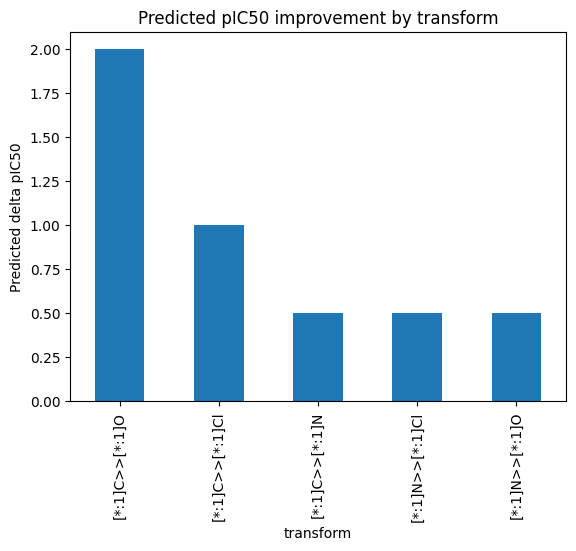

In [14]:
ax = stats_df.plot.bar(
    x="transform",
    y="predicted_delta",
    legend=False,
    title="Predicted pIC50 improvement by transform",
)
ax.set_ylabel("Predicted delta pIC50")
ax

## Apply Improving Rules To A New Molecule

`AnalysisResult.generate()` filters to improving transforms when a `property_name` is supplied, then applies those rules to the source molecule.

In [15]:
products = analysis.generate(
    "Cc1ccccc1",
    property_name="pIC50",
    min_evidence=2,
)
products.to_dataframe()

,smiles,transform,evidence_count,is_known_product,known_product_ids,property,predicted_delta,count,std,p_value
0,c1ccc(cc1)O,[*:1]C>>[*:1]O,2,True,['phenol'],pIC50,2.0,2,1.4142135623730951,0.2951672353008665


## Ask What Could Improve A Specific Molecule

Now let's get to asking some interesting questions of the data: `opportunities()` can be used to:

1) Suggest opportunities to improve a molecule
2) Generate potentially improved molecules

Let's start by looking at an example within the dataset. How could we make toluene more potent? In this case, let's limit our results to items with at least 2 example as evidence (`min_evidence=2`).

**1. What rules could be applied to `toluene` in order to improve it, and by how much?**

In [27]:
opportunities = analysis.opportunities(
    "toluene",
    property_name="pIC50",
    min_evidence=2,
)

# Display the rules (not showing molecules)
opportunities.rules.to_dataframe()

,transform,evidence_count,property,predicted_delta,count,std,p_value
0,[*:1]C>>[*:1]O,2,pIC50,2.0,2,1.4142135623730951,0.2951672353008665


**2. What are the actual pairs in the dataset that contribute to those rules?**

,source_id,target_id,constant,source_variable,target_variable,transform,cut_count,heavy_atom_delta,heavy_bond_delta,pIC50_delta
0,toluene,phenol,,,,,1,0,0,1.0

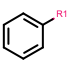
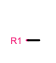
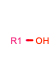
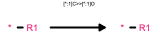

In [28]:
opportunities.pairs.to_dataframe(molecules=True)

There we can see that changing it to phenol could make it more potent.

**3. Give me the products of applying those rules to my input molecule `toluene`**

,smiles,transform,evidence_count,is_known_product,known_product_ids,property,predicted_delta,count,std,p_value
0,,,2,True,['phenol'],pIC50,2.0,2,1.4142135623730951,0.2951672353008665

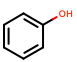
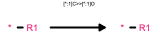

In [29]:
opportunities.products.to_dataframe(molecules=True)

What if we just wanted to see all transformations, regardless of our weight of evidence? Just omit `min_evidence`.

,source_id,target_id,constant,source_variable,target_variable,transform,cut_count,heavy_atom_delta,heavy_bond_delta,pIC50_delta
0,toluene,phenol,,,,,1,0,0,1.0
1,toluene,aniline,,,,,1,0,0,0.5
2,toluene,chlorophenyl,,,,,1,0,0,1.0

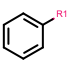
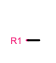
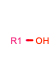
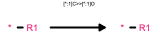
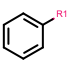
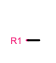
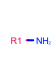
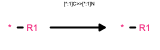
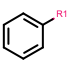
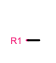
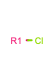
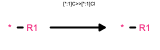

In [30]:
all_opportunities = analysis.opportunities(
    "toluene",
    property_name="pIC50",
)

# Look at the pairs that might improve pIC50
all_opportunities.pairs.to_dataframe(molecules=True)

Now we see aniline and chlorophenyl added as opportunities. There was only 1 example of each, so they were omitted when `min_evidence=2`. We can construct those products as well.

,smiles,transform,evidence_count,is_known_product,known_product_ids,property,predicted_delta,count,std,p_value
0,,,2,True,['phenol'],pIC50,2.0,2,1.4142135623730951,0.2951672353008665
1,,,1,True,['chlorophenyl'],pIC50,1.0,1,NaN,NaN
2,,,1,True,['aniline'],pIC50,0.5,1,NaN,NaN

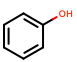
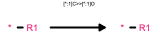
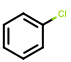
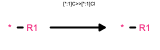
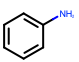
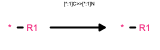

In [31]:
all_opportunities.products.to_dataframe(molecules=True)

#### How about suggestions for a completely novel molecule?

This is even more interesting than above. Let's say I have a molecule that definitely wasn't part of the original set.

<oechem.OEGraphMol; proxy of <Swig Object of type 'OEGraphMolWrapper *' at 0x3211f4a20> >
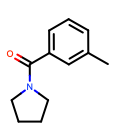

In [24]:
new_compound = oechem.OEGraphMol()
oechem.OESmilesToMol(new_compound, "Cc1cccc(c1)C(=O)N2CCCC2")

new_compound

What opportunities do we have here?

,smiles,transform,evidence_count,is_known_product,known_product_ids,property,predicted_delta,count,std,p_value
0,,,2,False,[],pIC50,2.0,2,1.4142135623730951,0.2951672353008665
1,,,1,False,[],pIC50,1.0,1,NaN,NaN
2,,,1,False,[],pIC50,0.5,1,NaN,NaN

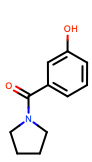
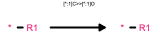
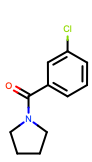
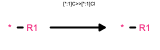
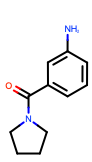
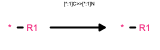

In [33]:
new_compound_opportunities = analysis.opportunities(
    new_compound,
    property_name="pIC50",
)

# You can look at the rules and products
# but let's skip right to the generation
new_compound_opportunities.products.to_dataframe(molecules=True)

## Find Molecules With One Change But Not Another

Because queries export plain dictionaries and dataframes, set logic remains straightforward. Here we ask for pyridine-constant molecules that have a carbon-to-oxygen change available, but not a carbon-to-nitrogen change.

In [23]:
pyridine_pairs = analysis.pairs.where_constant_matches("c1ccccn1")
carbon_to_oxygen_sources = {
    row["source_id"]
    for row in pyridine_pairs.where_variables_match(
        from_smarts="[#6]",
        to_smarts="[#8]",
    ).to_dicts()
}
carbon_to_nitrogen_sources = {
    row["source_id"]
    for row in pyridine_pairs.where_variables_match(
        from_smarts="[#6]",
        to_smarts="[#7]",
    ).to_dicts()
}

pd.DataFrame(
    {
        "source_id": sorted(carbon_to_oxygen_sources - carbon_to_nitrogen_sources),
    }
)

,source_id
0,methyl_pyridine
